In [84]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import missingno as msno
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score,recall_score,roc_curve, roc_auc_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier 
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler

In [2]:
df= pd.read_csv('Churn_Modelling.csv')

In [3]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42.0,2,0.00,1,1.0,1.0,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41.0,1,83807.86,1,0.0,1.0,112542.58,0
2,3,15619304,Onio,502,France,Female,42.0,8,159660.80,3,1.0,0.0,113931.57,1
3,4,15701354,Boni,699,France,Female,39.0,1,0.00,2,0.0,0.0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43.0,2,125510.82,1,NaN,1.0,79084.10,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10002 entries, 0 to 10001
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10002 non-null  int64  
 1   CustomerId       10002 non-null  int64  
 2   Surname          10002 non-null  object 
 3   CreditScore      10002 non-null  int64  
 4   Geography        10001 non-null  object 
 5   Gender           10002 non-null  object 
 6   Age              10001 non-null  float64
 7   Tenure           10002 non-null  int64  
 8   Balance          10002 non-null  float64
 9   NumOfProducts    10002 non-null  int64  
 10  HasCrCard        10001 non-null  float64
 11  IsActiveMember   10001 non-null  float64
 12  EstimatedSalary  10002 non-null  float64
 13  Exited           10002 non-null  int64  
dtypes: float64(5), int64(6), object(3)
memory usage: 1.1+ MB


In [5]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10002.000000,1.000200e+04,10002.000000,10001.000000,10002.000000,10002.000000,10002.000000,10001.000000,10001.000000,10002.000000,10002.000000
mean,5001.499600,1.569093e+07,650.555089,38.922311,5.012498,76491.112875,1.530194,0.705529,0.514949,100083.331145,0.203759
std,2887.472338,7.193177e+04,96.661615,10.487200,2.891973,62393.474144,0.581639,0.455827,0.499801,57508.117802,0.402812
min,1.000000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,11.580000,0.000000
25%,2501.250000,1.562852e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.000000,0.000000,50983.750000,0.000000
50%,5001.500000,1.569073e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.000000,1.000000,100185.240000,0.000000
75%,7501.750000,1.575323e+07,718.000000,44.000000,7.000000,127647.840000,2.000000,1.000000,1.000000,149383.652500,0.000000
max,10000.000000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.000000,1.000000,199992.480000,1.000000


In [6]:
df.isna().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          1
Gender             0
Age                1
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          1
IsActiveMember     1
EstimatedSalary    0
Exited             0
dtype: int64

In [7]:
df.fillna({
    "Geography": df["Geography"].mode()[0],
    "Tenure": df["Tenure"].median(),             
    "HasCrCard": df["HasCrCard"].mode()[0],     
    "IsActiveMember": df["IsActiveMember"].mode()[0]
}, inplace=True)


In [8]:
df.isna().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                1
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [63]:
df.fillna(df.median(), inplace=True)

In [9]:
df.duplicated().sum()

2

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df['CustomerId'].duplicated().sum()

0

In [12]:
df["AgeGroup"] = pd.cut(df["Age"], bins=[0, 30, 50, 100], labels=["Young", "Middle", "Senior"])

In [13]:
df["BalanceSalaryRatio"] = df["Balance"] / (df["EstimatedSalary"] + 1)

In [14]:
df["ProductsPerTenure"] = df["NumOfProducts"] / (df["Tenure"] + 1)

In [15]:
df["CreditAgeRatio"] = df["CreditScore"] / (df["Age"] + 1)

In [16]:
df["IsHighBalance"] = (df["Balance"] > df["Balance"].median()).astype(int)

In [17]:
df["TenureGroup"] = pd.cut(df["Tenure"], bins=[0, 3, 7, 10], labels=["New", "Mid", "Loyal"])

In [32]:
le = LabelEncoder()

In [33]:
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col].astype(str))

In [39]:
df["TenureGroup"] = df["TenureGroup"].astype(str).replace({
    "New": 0,
    "Mid": 1,
    "Loyal": 2
})

df["AgeGroup"] = df["AgeGroup"].astype(str).replace({
    "Young": 0,
    "Middle": 1,
    "Senior": 2
})

df["TenureGroup"] = df["TenureGroup"].astype(str).replace({
    "New": 0,
    "Mid": 1,
    "Loyal": 2
})


In [53]:
df.drop(['RowNumber','CustomerId','Surname','AgeGroup','TenureGroup','IsHighBalance'],axis=1, inplace=True)

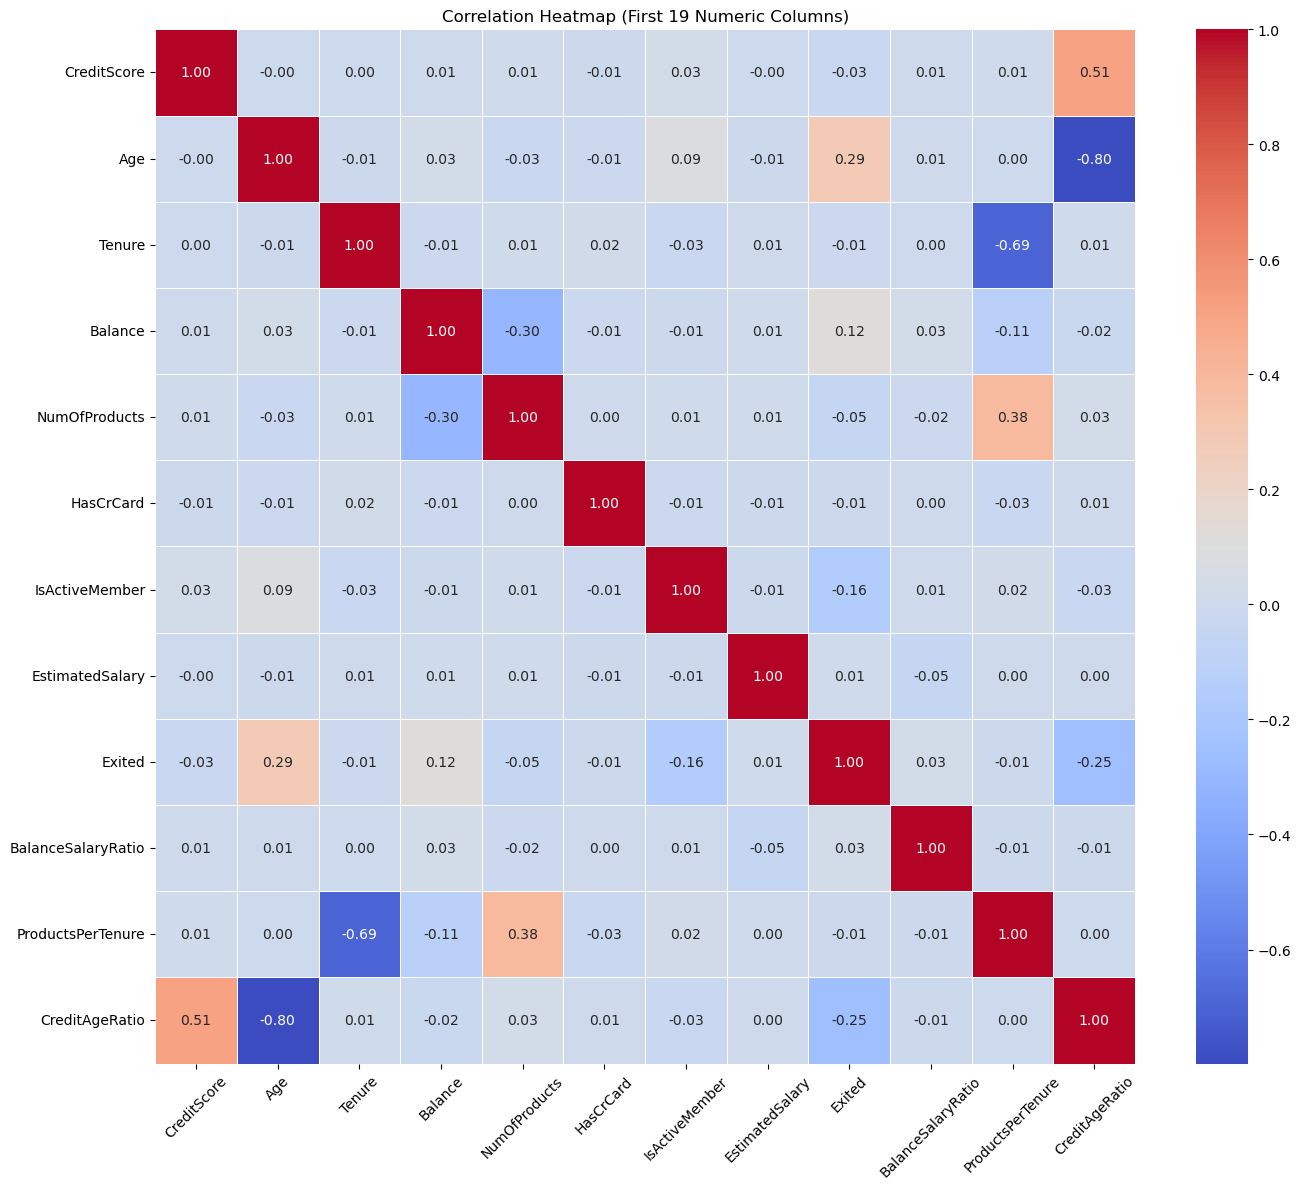

In [54]:
selected_cols = df.select_dtypes(include=['int64', 'float64']).columns[:19]
corr = df[selected_cols].corr()
plt.figure(figsize=(14, 12))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap (First 19 Numeric Columns)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [57]:
X=df.drop(['Exited'],axis=1)
y=df['Exited']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [58]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((8000, 13), (2000, 13), (8000,), (2000,))

In [64]:
y_train.value_counts(),y_test.value_counts()

(Exited
 0    6356
 1    1644
 Name: count, dtype: int64,
 Exited
 0    1607
 1     393
 Name: count, dtype: int64)

In [65]:
# SMOTE for class balance
smote=SMOTE()
X=df.drop('Exited',axis=1)
y=df['Exited']
X_smote,y_smote=smote.fit_resample(X,y)

In [66]:
y_smote.value_counts()

Exited
1    7963
0    7963
Name: count, dtype: int64

In [67]:
X_train,X_test,y_train,y_test=train_test_split(X_smote,y_smote,test_size=0.2,random_state=42)

In [68]:
#LogisticRegression
lg = LogisticRegression(class_weight='balanced', max_iter=1000)
lg.fit(X_train,y_train)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(class_weight='balanced', max_iter=1000)

In [69]:
pred_lr=lg.predict(X_test)
print('ACCuracy',accuracy_score(y_test,pred_lr))
print('Precition',precision_score(y_test,pred_lr))
print('recall',recall_score(y_test,pred_lr))
print('confusion_matrix',confusion_matrix(y_test,pred_lr))

ACCuracy 0.7407407407407407
Precition 0.7092688543465746
recall 0.7933032839665164
confusion_matrix [[1128  505]
 [ 321 1232]]


In [70]:
#DecisionTreeClassifier
clf= DecisionTreeClassifier()
clf =clf.fit(X_train,y_train)

[Text(0.5607679953843717, 0.9807692307692307, 'x[3] <= 40.0\ngini = 0.5\nsamples = 12740\nvalue = [6330, 6410]'),
 Text(0.3298894804317682, 0.9423076923076923, 'x[8] <= 1.0\ngini = 0.406\nsamples = 6372\nvalue = [4564.0, 1808.0]'),
 Text(0.4453287379080699, 0.9615384615384615, 'True  '),
 Text(0.1916778234675337, 0.9038461538461539, 'x[8] <= 0.003\ngini = 0.479\nsamples = 3637\nvalue = [2194, 1443]'),
 Text(0.19091278569379364, 0.8653846153846154, 'x[6] <= 1.5\ngini = 0.405\nsamples = 3054\nvalue = [2194, 860]'),
 Text(0.10653300420770775, 0.8269230769230769, 'x[2] <= 0.5\ngini = 0.481\nsamples = 1687\nvalue = [1008, 679]'),
 Text(0.04347267380701922, 0.7884615384615384, 'x[7] <= 0.001\ngini = 0.497\nsamples = 890\nvalue = [411.0, 479.0]'),
 Text(0.021666108826623315, 0.75, 'x[5] <= 129484.695\ngini = 0.437\nsamples = 183\nvalue = [124.0, 59.0]'),
 Text(0.012730706703643492, 0.7115384615384616, 'x[11] <= 0.133\ngini = 0.466\nsamples = 138\nvalue = [87, 51]'),
 Text(0.005355264416180548

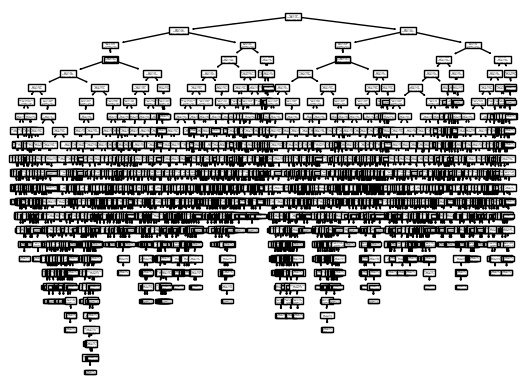

In [71]:
tree.plot_tree(clf)

In [72]:
#Feature Importance Analysis
importances = clf.feature_importances_
feature_importance = pd.Series(importances, index=X_train.columns)
important_features = feature_importance.sort_values(ascending=False)
print(important_features.head(10))

Age                   0.278522
IsActiveMember        0.208428
NumOfProducts         0.077982
EstimatedSalary       0.065141
Balance               0.062866
CreditScore           0.059938
CreditAgeRatio        0.051893
ProductsPerTenure     0.043099
BalanceSalaryRatio    0.038491
HasCrCard             0.033447
dtype: float64


In [73]:
pred_clf = clf.predict(X_test)
print("precision",precision_score(y_test,pred_clf))
print("recall",recall_score(y_test,pred_clf))
print('confusion_matrix',confusion_matrix(y_test,pred_clf))

precision 0.8225
recall 0.8473921442369607
confusion_matrix [[1349  284]
 [ 237 1316]]


In [74]:
scores = cross_val_score(clf, X, y, cv=5, scoring='accuracy')
print("Cross-Validation Accuracy:", scores.mean())

Cross-Validation Accuracy: 0.7861


In [75]:
#RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100,class_weight='balanced',random_state=42,n_jobs=-1)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

In [76]:
print('ACCuracy',accuracy_score(y_test,pred_rf))
print('Precition',precision_score(y_test,pred_rf))
print('recall',recall_score(y_test,pred_rf))
print('confusion_matrix',confusion_matrix(y_test,pred_rf))

ACCuracy 0.8935969868173258
Precition 0.9079301075268817
recall 0.8699291693496458
confusion_matrix [[1496  137]
 [ 202 1351]]


In [77]:
#XGBClassifier
xgb = XGBClassifier()
xgb.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [78]:
pred_xgb= xgb.predict(X_test)
print('ACCuracy',accuracy_score(y_test,pred_xgb))
print('Precition',precision_score(y_test,pred_xgb))
print('recall',recall_score(y_test,pred_xgb))
print('confusion_matrix',confusion_matrix(y_test,pred_xgb))

ACCuracy 0.9055241682360327
Precition 0.9206989247311828
recall 0.8821635544108177
confusion_matrix [[1515  118]
 [ 183 1370]]


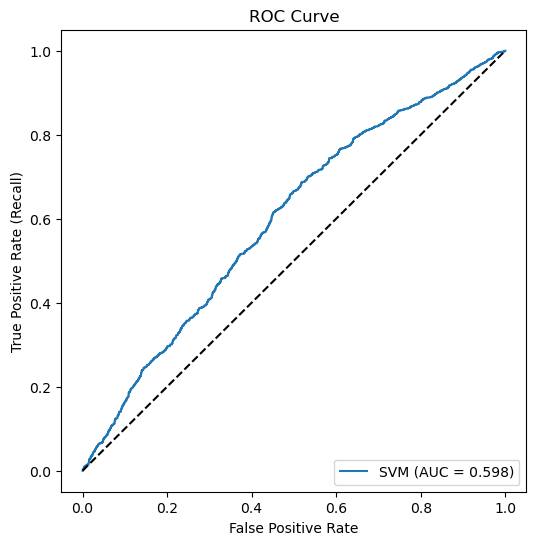

In [85]:
y_prob = svm.decision_function(X_test)
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label="SVM (AUC = %.3f)" % auc)
plt.plot([0,1], [0,1], 'k--')  # خط عشوائي
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

In [79]:
#SVM
svm=SVC()
svm.fit(X_train,y_train)

SVC()

In [81]:
pred_svm=svm.predict(X_test)
print('ACCuracy',accuracy_score(y_test,pred_svm))
print('Precition',precision_score(y_test))
print('recall',recall_score(y_test,pred_svm))
print('confusion_matrix',confusion_matrix(y_test,pred_svm))

ACCuracy 0.5725047080979284


TypeError: missing a required argument: 'y_pred'